In [9]:
import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 设置绘图风格，支持图表中显示中文
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 如果在 Mac 或 Linux 下报错，可以注释掉此行
plt.rcParams['axes.unicode_minus'] = False

print("✅ 环境与库导入成功！")

✅ 环境与库导入成功！


In [10]:
print("1. 开始加载 MI-EEG 数据集...")

# 确保这四个文件与当前 notebook 在同一目录下
# 直接读取并将特征数据重塑为 (样本数, 3通道, 1000时间点)
X_train_raw = pd.read_csv('MI-EEG-B9T.csv', header=None).values.reshape(-1, 3, 1000)
X_test_raw  = pd.read_csv('MI-EEG-B9E.csv', header=None).values.reshape(-1, 3, 1000)
y_train     = pd.read_csv('2class_MI_EEG_train_9.csv', header=None).values.flatten()
y_test      = pd.read_csv('2class_MI_EEG_test_9.csv', header=None).values.flatten()

FS = 250 # 采样率

print(f"训练集特征形状: {X_train_raw.shape}, 标签形状: {y_train.shape}")
print(f"测试集特征形状: {X_test_raw.shape}, 标签形状: {y_test.shape}")

1. 开始加载 MI-EEG 数据集...
训练集特征形状: (400, 3, 1000), 标签形状: (400,)
测试集特征形状: (320, 3, 1000), 标签形状: (320,)


In [11]:
print("2. 信号降噪：带通滤波 (8-30 Hz) + Z-Score 标准化...")

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_filter_and_norm(data):
    # 1. 提取运动想象相关的 Mu 和 Beta 频段，滤除低频眨眼噪声
    b, a = butter_bandpass(8.0, 30.0, FS, order=4)
    data_filtered = lfilter(b, a, data, axis=2)
    
    # 2. 按通道进行 Z-score 标准化，消除异常尖峰极值的影响
    data_norm = np.zeros_like(data_filtered)
    for i in range(data.shape[0]):
        for c in range(data.shape[1]):
            mean = np.mean(data_filtered[i, c, :])
            std = np.std(data_filtered[i, c, :])
            data_norm[i, c, :] = (data_filtered[i, c, :] - mean) / (std + 1e-8)
    return data_norm

X_train_clean = apply_filter_and_norm(X_train_raw)
X_test_clean  = apply_filter_and_norm(X_test_raw)

print("✅ 数据清洗与预处理完成！")

2. 信号降噪：带通滤波 (8-30 Hz) + Z-Score 标准化...
✅ 数据清洗与预处理完成！


3. 执行实验要求：连续小波变换 (CWT) 生成二维图像 (大约需要1-2分钟)...
生成的图像数据形状: (400, 40, 1000, 3)


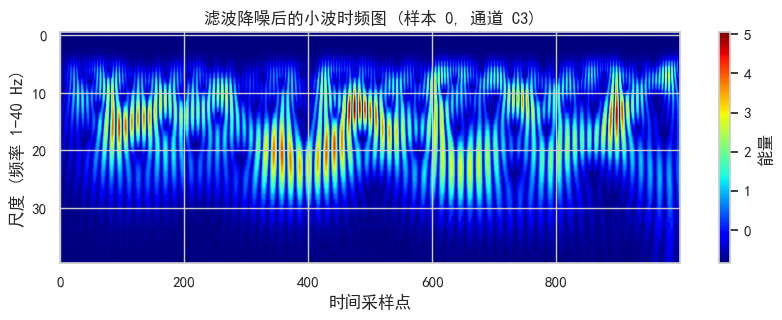

In [12]:
print("3. 执行实验要求：连续小波变换 (CWT) 生成二维图像 (大约需要1-2分钟)...")

def generate_robust_cwt_images(data):
    scales = np.arange(1, 41) # 提取 1-40 Hz 的尺度
    images = []
    for i in range(data.shape[0]):
        img_channels = []
        for c in range(data.shape[1]):
            signal = data[i, c, :]
            coef, _ = pywt.cwt(signal, scales, 'morl', sampling_period=1/FS)
            cwt_img = np.abs(coef)
            
            # 对图像像素进行均值化处理，突出特征
            cwt_img = (cwt_img - np.mean(cwt_img)) / (np.std(cwt_img) + 1e-8)
            img_channels.append(cwt_img)
            
        # 叠加三个物理通道形成 RGB 图片深度
        img = np.stack(img_channels, axis=-1)
        images.append(img)
    return np.array(images)

X_train_img = generate_robust_cwt_images(X_train_clean)
X_test_img  = generate_robust_cwt_images(X_test_clean)

print(f"生成的图像数据形状: {X_train_img.shape}")

# 可视化清洗后的小波图像 (不再是一片黑，能看到清晰的能量分布)
plt.figure(figsize=(10, 3))
plt.imshow(X_train_img[0, :, :, 0], aspect='auto', cmap='jet')
plt.title("滤波降噪后的小波时频图 (样本 0, 通道 C3)")
plt.colorbar(label="能量")
plt.xlabel("时间采样点")
plt.ylabel("尺度 (频率 1-40 Hz)")
plt.show()

In [13]:
print("4. 构建并训练 2D-CNN 神经网络...")

# 构建轻量级的高强正则化网络，防止过拟合
model = models.Sequential([
    layers.Conv2D(16, (3, 5), activation='relu', input_shape=(40, 1000, 3)),
    layers.MaxPooling2D((2, 4)),
    layers.BatchNormalization(),
    
    layers.Conv2D(32, (3, 5), activation='relu'),
    layers.MaxPooling2D((2, 4)),
    layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.6), # 极强的 Dropout 遏制网络瞎猜
    layers.Dense(1, activation='sigmoid') # 二分类：左右手
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 加入早停机制：如果验证集损失连续 8 轮不下降，就提前停止并恢复最佳参数
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

# 开始训练
history = model.fit(
    X_train_img, y_train, 
    epochs=30, 
    batch_size=16, # 小 Batch 提升网络鲁棒性
    validation_split=0.2, 
    callbacks=[callback], 
    verbose=1
)

4. 构建并训练 2D-CNN 神经网络...
Epoch 1/30
20/20 [==============================] - 2s 105ms/step - loss: 1.2812 - accuracy: 0.4875 - val_loss: 0.6883 - val_accuracy: 0.5750
Epoch 2/30
20/20 [==============================] - 2s 96ms/step - loss: 0.6725 - accuracy: 0.5531 - val_loss: 0.6853 - val_accuracy: 0.5625
Epoch 3/30
20/20 [==============================] - 2s 96ms/step - loss: 0.6694 - accuracy: 0.6187 - val_loss: 0.6703 - val_accuracy: 0.6125
Epoch 4/30
20/20 [==============================] - 2s 95ms/step - loss: 0.6219 - accuracy: 0.6187 - val_loss: 0.6517 - val_accuracy: 0.6250
Epoch 5/30
20/20 [==============================] - 2s 95ms/step - loss: 0.5876 - accuracy: 0.6969 - val_loss: 0.6701 - val_accuracy: 0.5875
Epoch 6/30
20/20 [==============================] - 2s 94ms/step - loss: 0.5736 - accuracy: 0.6656 - val_loss: 0.6780 - val_accuracy: 0.6375
Epoch 7/30
20/20 [==============================] - 2s 96ms/step - loss: 0.5437 - accuracy: 0.7031 - val_loss: 0.6594 - val_accur

5. 测试集最终评估与可视化...

✅ 最终测试集准确率 (Test Accuracy): 70.94%

10/10 [==============================] - 0s 38ms/step
分类评估报告:
              precision    recall  f1-score   support

    想象左手 (0)       0.68      0.78      0.73       160
    想象右手 (1)       0.74      0.64      0.69       160

    accuracy                           0.71       320
   macro avg       0.71      0.71      0.71       320
weighted avg       0.71      0.71      0.71       320



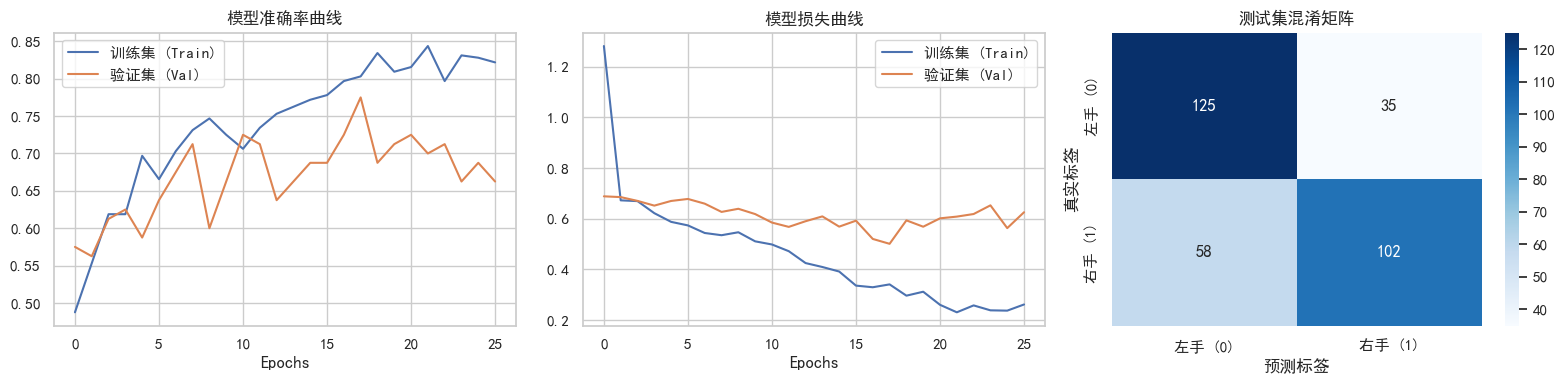

In [14]:
print("5. 测试集最终评估与可视化...")

# 评估测试集
test_loss, test_acc = model.evaluate(X_test_img, y_test, verbose=0)
print(f"\n======================================")
print(f"✅ 最终测试集准确率 (Test Accuracy): {test_acc * 100:.2f}%")
print(f"======================================\n")

y_pred_prob = model.predict(X_test_img)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("分类评估报告:")
print(classification_report(y_test, y_pred, target_names=['想象左手 (0)', '想象右手 (1)']))

# 绘制实验报告所需的图表
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 准确率图
axes[0].plot(history.history['accuracy'], label='训练集 (Train)')
axes[0].plot(history.history['val_accuracy'], label='验证集 (Val)')
axes[0].set_title('模型准确率曲线')
axes[0].set_xlabel('Epochs')
axes[0].legend()

# 损失图
axes[1].plot(history.history['loss'], label='训练集 (Train)')
axes[1].plot(history.history['val_loss'], label='验证集 (Val)')
axes[1].set_title('模型损失曲线')
axes[1].set_xlabel('Epochs')
axes[1].legend()

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], 
            xticklabels=['左手 (0)', '右手 (1)'], 
            yticklabels=['左手 (0)', '右手 (1)'])
axes[2].set_title('测试集混淆矩阵')
axes[2].set_ylabel('真实标签')
axes[2].set_xlabel('预测标签')

plt.tight_layout()
plt.show()